# Networks, language, and emotions during a Californian emergency on Bluesky

**Network structure:** Nodes represent users; edges capture likes, reposts, and comments.

**Emotion vs. influence:** Are the most reposted posts also the most emotional?

**Community detection:** Identify user communities through interaction networks (e.g., Louvain algorithm).

**Community language:** Analyze each community's vocabulary using TF-IDF.

**Behavioral differences:** Compare communities by sentiment (how they *feel*) and vocabulary (how they *talk*), and track how it evolves (before, during, and after the disaster).

**Information roles:** Identify authorities, misinformation spreaders, and bridge nodes (e.g., science communicators) and examine how their language differs.

## Getting the posts and interactions

### Data preprocessing

- Preprocess the posts by lower-casing, removing words following @/# (e.g. hashtags, mentions), URLs and emojis, non-English texts via `langdetect`, and English stop-words

In [ ]:
from fetch_data import fetch_posts
from preprocess_data import preprocess_posts_and_interactions

# Fetch data (not necessary if jsonl files already exist)
# fetch_posts()

# Preprocess data
posts, interact_filtered = preprocess_posts_and_interactions("../data/bluesky/ca_fire_20250101_20250207.jsonl", "../data/bluesky/interactions_20250101_20250207.jsonl")

=== dataset cleaning & dedupe ===
Rows after scanning-spam filter (before dedupe): 1259
Rows after dedupe by uri: 1259

=== URI / interaction summary (unique-URI basis) ===
Total unique clean posts: 1,259
Unique post URIs that appear as interaction targets (in our interact file): 754
Unique post URIs with zero interactions: 505
Check sum (unique targets + lonely) == total_unique_posts -> 1259 == 1259

=== interactions (filtered to posts we retained) ===
Total interaction rows (original interactions file): 8,809
Interaction rows after filtering to dst_uri in our posts: 8,608
Interaction types (filtered):
like    : 6,792
repost  : 1,323
reply   : 493

Distinct users (authors in posts ∪ src_did of filtered interactions): 6,518

=== first 10 cleaned posts (after filtering & dedupe) ===
                                                                                                   ap.com: utility says equipment likely started small blaze erupted january's la firestorm
                   

### Data exploration
- Basic network statistics
- Comparison of "fire"-related posts tagged within `#California` in January 2025 versus the rest of the year (until October).
- Temporal distribution of posts during January 2025 and early February 2025.

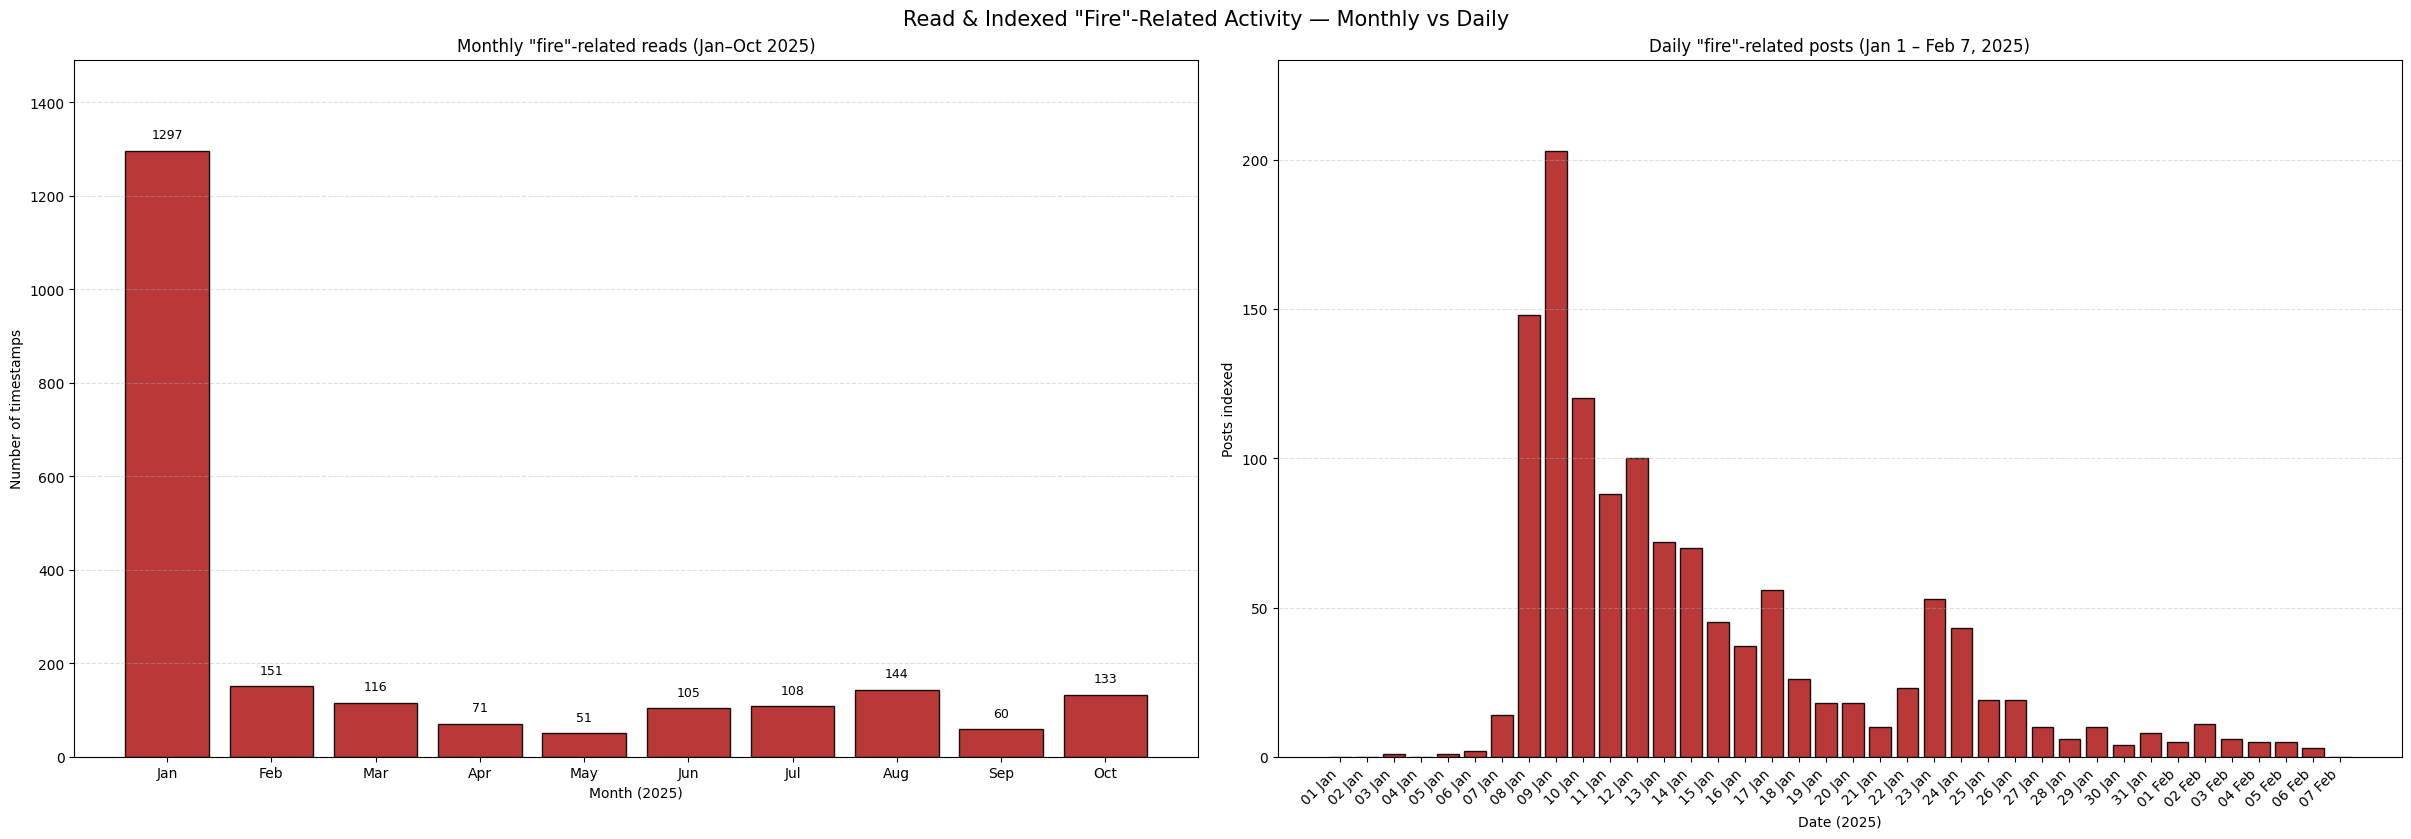

In [3]:
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) MONTHLY COUNTS FROM all_read_dates.txt
# ------------------------------------------------------------
months = []
with open('all_read_dates.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        dt = datetime.fromisoformat(line)
        if dt.year == 2025:          # only keep 2025
            months.append(dt.month)

month_counts = Counter(months)

# Only Jan–Oct
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct"]
counts = [month_counts.get(i, 0) for i in range(1, 11)]


# ------------------------------------------------------------
# 2) DAILY COUNTS FROM posts DATAFRAME
# ------------------------------------------------------------
# posts must already exist in memory with an "indexed_at" column
posts["day"] = pd.to_datetime(posts["indexed_at"], utc=True).dt.date
daily_counts = posts["day"].value_counts().sort_index()

daily_dates = pd.to_datetime(daily_counts.index)
daily_vals  = daily_counts.values


# ------------------------------------------------------------
# 3) VISUALIZATION — two histograms in parallel
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(24, 8), constrained_layout=True)


# ===== LEFT: Monthly histogram =====
ax = axes[0]
xpos = np.arange(len(month_names))

ax.bar(xpos, counts, color='firebrick', edgecolor='black', alpha=0.90)
ax.set_xticks(xpos)
ax.set_xticklabels(month_names)
ax.set_xlabel("Month (2025)")
ax.set_ylabel("Number of timestamps")
ax.set_title("Monthly \"fire\"-related reads (Jan–Oct 2025)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

# annotate bars
for x, y in zip(xpos, counts):
    if y > 0:
        ax.text(x, y + max(counts)*0.015, str(y),
                ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, max(counts)*1.15 if max(counts) > 0 else 1)


# ===== RIGHT: Daily histogram =====
# --- Ensure ALL days from Jan 1 → Feb 7 are included ---
date_range = pd.date_range(start="2025-01-01", end="2025-02-07", freq="D")

# Convert to date objects for matching posts["day"]
date_range_dates = date_range.date

# Reindex daily_counts to include missing days (filling with 0)
daily_counts_full = (
    posts["day"].value_counts()
    .reindex(date_range_dates, fill_value=0)
)

# Extract arrays for plotting
full_dates = pd.to_datetime(daily_counts_full.index)
full_vals  = daily_counts_full.values

# --- Plot ---
ax = axes[1]

ax.bar(full_dates, full_vals, width=0.8, color='firebrick',
       edgecolor='black', alpha=0.90)

ax.set_xlabel("Date (2025)")
ax.set_ylabel("Posts indexed")
ax.set_title('Daily "fire"-related posts (Jan 1 – Feb 7, 2025)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# --- Create labels for ALL days (Jan + Feb) ---
tick_labels = [dt.strftime("%d %b") for dt in full_dates]

ax.set_xticks(full_dates)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')

# Y-axis autoscale
ax.set_ylim(0, max(full_vals) * 1.15 if max(full_vals) > 0 else 1)


# ------------------------------------------------------------
# 4) Overall title
# ------------------------------------------------------------
fig.suptitle('Read & Indexed "Fire"-Related Activity — Monthly vs Daily',
             fontsize=15, y=1.03)

plt.show()

## Network analysis

In [4]:
import networkx as nx
import numpy as np
import pandas as pd

# --- prepare mapping uri -> author_did (ensure no NaNs) ---
uri_to_author = posts.set_index('uri')['author_did'].to_dict()

# --- build directed graph, using weight to count multiple interactions ---
G = nx.DiGraph()
# add all users as nodes (optional but helpful)
all_users = set(posts['author_did'].dropna()) | set(interact_filtered['src_did'].dropna())
G.add_nodes_from(all_users)

# iterate interactions and add edges (src_did -> author_did_of_dst_uri)
edge_rows = 0
missing_targets = 0
for r in interact_filtered.itertuples(index=False):
    src = getattr(r, 'src_did', None)
    dst_uri = getattr(r, 'dst_uri', None)
    if pd.isna(src) or pd.isna(dst_uri):
        continue
    dst = uri_to_author.get(dst_uri)
    if dst is None:
        missing_targets += 1
        continue
    edge_rows += 1
    if G.has_edge(src, dst):
        G[src][dst]['weight'] += 1
    else:
        G.add_edge(src, dst, weight=1)

print(f"Interaction rows processed into edges: {edge_rows:,}  (missing targets: {missing_targets:,})")
print(f"Nodes in graph: {G.number_of_nodes():,}, edges (unique pairs): {G.number_of_edges():,}")
print()

# --- degree measures ---
# unweighted (number of distinct neighbours)
in_deg_unw = dict(G.in_degree())           # number of incoming neighbors (unweighted)
out_deg_unw = dict(G.out_degree())         # number of outgoing neighbors (unweighted)

# weighted (sum of interaction counts)
in_deg_w = dict(G.in_degree(weight='weight'))
out_deg_w = dict(G.out_degree(weight='weight'))

# convert to pandas Series for convenient stats and filtering
s_in_unw  = pd.Series(in_deg_unw).astype(int)
s_out_unw = pd.Series(out_deg_unw).astype(int)
s_in_w    = pd.Series(in_deg_w).astype(int)
s_out_w   = pd.Series(out_deg_w).astype(int)

# --- for the moment no restriction in interacting users ---
# For in-degree stats: users with in-degree >= 0 (no restriction)
in_users_mask_unw  = s_in_unw >= 0
in_users_mask_w    = s_in_w >= 0

# For out-degree stats: users with out-degree >= 0 (no restriction)
out_users_mask_unw = s_out_unw >= 0
out_users_mask_w   = s_out_w >= 0

def print_stats(series, label):
    arr = series.values
    print(label)
    print(f" Count: {len(arr):,}")
    if len(arr) == 0:
        print("  (no data)\n")
        return
    print(f" Mean  : {arr.mean():.3f}")
    print(f" Median: {np.median(arr):.0f}")
    print(f" Min   : {arr.min():.0f}")
    print(f" Max   : {arr.max():.0f}")
    print(f" Std   : {arr.std(ddof=0):.3f}")   # population std
    print()

# --- print concise stats ---
print("=== UNWEIGHTED degree stats (counts of distinct neighbours) ===")
print_stats(s_in_unw[in_users_mask_unw],  "In-degree (users with in-degree >= 0)")
print_stats(s_out_unw[out_users_mask_unw],"Out-degree (users with out-degree >= 0)")

print("=== WEIGHTED degree stats (sum of interaction counts per node) ===")
print_stats(s_in_w[in_users_mask_w],      "Weighted in-degree (users with weighted in-degree >= 0)")
print_stats(s_out_w[out_users_mask_w],    "Weighted out-degree (users with weighted out-degree >= 0)")

# --- optional: show top-k contributors/receivers ---
TOP_K = 10
print("Top receivers by weighted in-degree (user_did, weight):")
print(s_in_w.sort_values(ascending=False).head(TOP_K).to_string())
print()
print("Top sources by weighted out-degree (user_did, weight):")
print(s_out_w.sort_values(ascending=False).head(TOP_K).to_string())

Interaction rows processed into edges: 8,608  (missing targets: 0)
Nodes in graph: 6,518, edges (unique pairs): 6,762

=== UNWEIGHTED degree stats (counts of distinct neighbours) ===
In-degree (users with in-degree >= 0)
 Count: 6,518
 Mean  : 1.037
 Median: 0
 Min   : 0
 Max   : 776
 Std   : 16.560

Out-degree (users with out-degree >= 0)
 Count: 6,518
 Mean  : 1.037
 Median: 1
 Min   : 0
 Max   : 77
 Std   : 1.156

=== WEIGHTED degree stats (sum of interaction counts per node) ===
Weighted in-degree (users with weighted in-degree >= 0)
 Count: 6,518
 Mean  : 1.321
 Median: 0
 Min   : 0
 Max   : 959
 Std   : 21.519

Weighted out-degree (users with weighted out-degree >= 0)
 Count: 6,518
 Mean  : 1.321
 Median: 1
 Min   : 0
 Max   : 77
 Std   : 1.585

Top receivers by weighted in-degree (user_did, weight):
did:plc:4l3smgwfawe4g4g67xynzkb7    959
did:plc:r64wzjtkimyq4vkiddzuu6no    917
did:plc:vqcodp4ycm7mxxnncn66iat5    693
did:plc:w4shf2bmiz2dvzqq6yuyvg6n    457
did:plc:yqfmy2p54vqgek